# Connectome as a Valence Estimator (perception-only)

**Question.** The larva olfactory circuit (ORN→KC→MBON) computes *valence* — "am I
moving up-gradient?" — not motor commands. So instead of end-to-end steering, we use
the real connectome as a **valence estimator** and ask the cleanest question it can
actually answer:

> Given only the bilateral sensor stream over time, can the connectome reconstruct
> **dlog** (the temporal change of log-concentration)?

dlog is computable by the circuit (a temporal derivative of its own inputs); absolute
distance / global bearing are not — so dlog is the biologically honest target.

**Why this is easy + rigorous.** Supervised regression (dense gradient, backprop) — no
sparse-reward RL. We compare the connectome against baselines that *cannot* integrate
over time, so beating them proves the recurrence does real temporal integration.

## 1. Setup

In [1]:
import os, sys, subprocess
if os.path.isdir('/content'):
    # --- Colab: clone the repo (no Drive mount needed) ---
    REPO_URL = 'https://github.com/InHyunseo/Brain-inspired-OSL.git'
    REPO_DIR = '/content/2d-osl'
    if not os.path.isdir(REPO_DIR):
        subprocess.check_call(['git','clone','--depth','1', REPO_URL, REPO_DIR])
else:
    # --- Local: find the repo root (dir containing src/) ---
    REPO_DIR=os.path.abspath(os.getcwd())
    while not os.path.isdir(os.path.join(REPO_DIR,'src')) and REPO_DIR!=os.path.dirname(REPO_DIR):
        REPO_DIR=os.path.dirname(REPO_DIR)
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path: sys.path.insert(0,REPO_DIR)
print('repo:', REPO_DIR)

import numpy as np, torch
import matplotlib.pyplot as plt
from src.brain.valence_connectome import ValenceConnectome
from src.brain.train_valence import make_dataset, to_tensors, baseline_scores, train, masked_mse
print('imports OK | torch', torch.__version__)

repo: /content/2d-osl
imports OK | torch 2.11.0+cu128


## 2. Config (edit here)

In [2]:
# Input is now 5-D: [c_left, c_right, v, body_omega, head_omega]. dlog is a
# sensor x action interaction, so the action (efference) channels are required —
# sensors alone cannot predict dlog (verified: linear-on-sensors barely beats 0).

# dataset  (Colab-sized; shrink N_EPISODES/SEQ_T if you hit RAM limits locally)
N_EPISODES   = 600      # random-policy rollouts
EP_LEN       = 120
SEQ_T        = 120
DATA_SEED    = 0
ENV_KW = dict(success_radius_mm=7.5, gaussian_sigma_mm=30.0, episode_seconds=120.0,
              sensor_spacing_mm=0.15)

# connectome
IN_DIM       = 5        # sensors(2) + efference action(3)
INNER_STEPS  = 6        # message-passing steps/env step (deeper = better nonlinearity)
N_OUT_NODES  = 8

# training
EPOCHS       = 120
LR           = 1e-2
BATCH        = 64
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


## 3. Build dataset (sensor sequence → dlog GT)

Random-policy rollouts give diverse sensor patterns. Input = (c_left, c_right) per
step; target = dlog (already computed by the env).

In [3]:
print('generating dataset ...')
S, D = make_dataset(n_episodes=N_EPISODES, ep_len=EP_LEN, seed=DATA_SEED, env_kw=ENV_KW)
Sx, Dy, mask = to_tensors(S, D, T=SEQ_T, device=DEVICE)
print('episodes:', Sx.shape[0], '| padded T:', Sx.shape[1], '| valid steps:', int(mask.sum().item()))
print('dlog target — mean %.4f  std %.4f' % (Dy[mask.bool()].mean().item(), Dy[mask.bool()].std().item()))

generating dataset ...
episodes: 600 | padded T: 120 | valid steps: 71699
dlog target — mean 0.0148  std 0.2130


## 4. Baselines (no temporal memory)

- **const-0**: predict 0 always → MSE = variance of dlog (trivial floor).
- **instantaneous-linear**: best linear map of (c_L, c_R, c_L−c_R) → can a purely
  *spatial* readout fake the temporal derivative? (closed-form least squares)

In [4]:
bl = baseline_scores(Sx.cpu(), Dy.cpu(), mask.cpu())
print('const-0 MSE             : %.5f   (dlog variance, trivial floor)' % bl['const0_mse'])
print('linear (no interaction): %.5f   (best linear map of sensors+action)' % bl['linear_mse'])
print('linear + interaction   : %.5f   (adds sensor x action terms = predictable ceiling)' % bl['interaction_mse'])
print('  -> %.0f%% of dlog is predictable, and ONLY via the sensor x action interaction'
      % (100*(bl['const0_mse']-bl['interaction_mse'])/bl['const0_mse']))

const-0 MSE             : 0.04559   (dlog variance, trivial floor)
linear (no interaction): 0.04522   (best linear map of sensors+action)
linear + interaction   : 0.00592   (adds sensor x action terms = predictable ceiling)
  -> 87% of dlog is predictable, and ONLY via the sensor x action interaction


## 5. Train the connectome valence regressor

In [5]:
model = ValenceConnectome(in_dim=IN_DIM, n_output_nodes=N_OUT_NODES, inner_steps=INNER_STEPS).to(DEVICE)
print('connectome:', model.describe())
res = train(model, Sx, Dy, mask, epochs=EPOCHS, lr=LR, batch=BATCH, seed=0, verbose=True)
print('\nbest val MSE:', round(res['best_val_mse'],5))

connectome: {'nodes': 399, 'edges': 15952, 'params': 18355, 'inner_steps': 6, 'output_nodes': 8}
  epoch   0  val_mse 0.04613  (best 0.04613)
  epoch   5  val_mse 0.04616  (best 0.04613)
  epoch  10  val_mse 0.04614  (best 0.04595)
  epoch  15  val_mse 0.04613  (best 0.04595)
  epoch  20  val_mse 0.04613  (best 0.04595)
  epoch  25  val_mse 0.04613  (best 0.04595)
  epoch  30  val_mse 0.04614  (best 0.04595)
  epoch  35  val_mse 0.04613  (best 0.04595)
  epoch  40  val_mse 0.04613  (best 0.04595)
  epoch  45  val_mse 0.04612  (best 0.04595)
  epoch  50  val_mse 0.04613  (best 0.04595)
  epoch  55  val_mse 0.04612  (best 0.04595)
  epoch  60  val_mse 0.04613  (best 0.04595)
  epoch  65  val_mse 0.04615  (best 0.04595)
  epoch  70  val_mse 0.04613  (best 0.04595)
  epoch  75  val_mse 0.04615  (best 0.04595)
  epoch  80  val_mse 0.04617  (best 0.04595)
  epoch  85  val_mse 0.04613  (best 0.04595)
  epoch  90  val_mse 0.04612  (best 0.04595)
  epoch  95  val_mse 0.04613  (best 0.04595)
  e

## 6. Result — does the connectome beat the memory-less baselines?

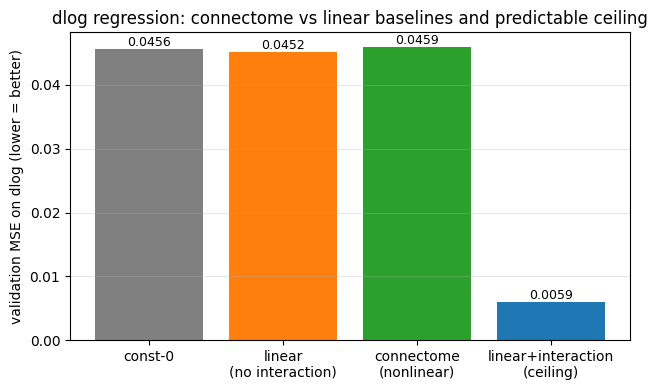

connectome beats linear (no-interaction): False
connectome captured -1% of the predictable structure (interaction ceiling = 100%)


In [6]:
conn = res['best_val_mse']
names = ['const-0','linear\n(no interaction)','connectome\n(nonlinear)','linear+interaction\n(ceiling)']
vals  = [bl['const0_mse'], bl['linear_mse'], conn, bl['interaction_mse']]
fig, ax = plt.subplots(figsize=(6.5,4))
bars = ax.bar(names, vals, color=['gray','tab:orange','tab:green','tab:blue'])
ax.set_ylabel('validation MSE on dlog (lower = better)')
ax.set_title('dlog regression: connectome vs linear baselines and predictable ceiling')
for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y',alpha=.3); plt.tight_layout(); plt.show()

print('connectome beats linear (no-interaction):', conn < bl['linear_mse'])
# how far from the predictable ceiling did the nonlinear circuit get?
span = bl['const0_mse'] - bl['interaction_mse']
got  = bl['const0_mse'] - conn
print('connectome captured %.0f%% of the predictable structure (interaction ceiling = 100%%)'
      % (100*got/span if span>0 else 0))

## 7. Qualitative — predicted vs true dlog on a held-out episode

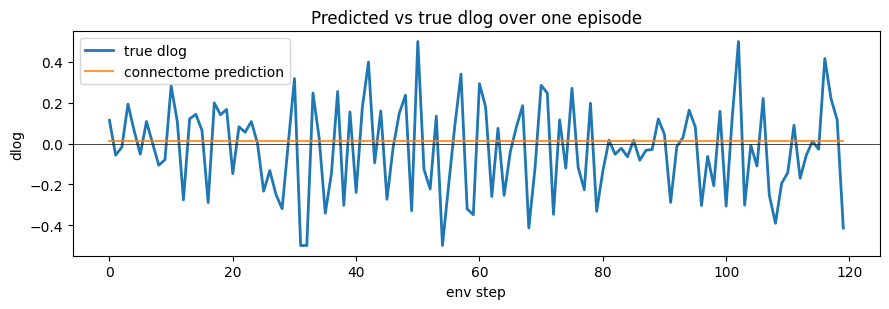

correlation: nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [7]:
model.eval()
with torch.no_grad():
    i = 0  # episode index to view
    pred = model(Sx[i:i+1])[0,:,0].cpu().numpy()
T = int(mask[i].sum().item())
true = Dy[i,:T,0].cpu().numpy(); pred = pred[:T]
fig, ax = plt.subplots(figsize=(9,3.2))
ax.plot(true, label='true dlog', lw=2)
ax.plot(pred, label='connectome prediction', lw=1.5, alpha=.8)
ax.axhline(0, color='k', lw=.5)
ax.set_xlabel('env step'); ax.set_ylabel('dlog'); ax.legend()
ax.set_title('Predicted vs true dlog over one episode')
plt.tight_layout(); plt.show()
print('correlation:', round(float(np.corrcoef(true,pred)[0,1]),3))

## 8. (optional) Save the trained connectome

In [ ]:
from pathlib import Path
OUT = Path('runs')/'valence_connectome'; OUT.mkdir(parents=True, exist_ok=True)
torch.save({'state_dict':model.state_dict(),'describe':model.describe(),
            'best_val_mse':res['best_val_mse'],'baselines':bl,
            'config':dict(inner_steps=INNER_STEPS,n_out=N_OUT_NODES,env_kw=ENV_KW)},
           OUT/'valence_connectome.pt')
print('saved', OUT/'valence_connectome.pt')